In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_PRIMA = pd.read_csv(r"/home/macraedc/data/uncertainty_project/UQ_PRIMA_2025.csv", sep=';')

In [3]:

ALL_DFS_DICT = {
    'Xerostomia_M06' : {
        "no Pharynx": pd.read_csv("/home/macraedc/UQ_results/MC Dropout no Pharynx in training/Xerostomia_M06/model_1/all_predictions.csv", sep=';'),
        "no Larynx": pd.read_csv("/home/macraedc/UQ_results/MC Dropout no Larynx in training/Xerostomia_M06/model_1/all_predictions.csv", sep=';'),
   },
   'Dysphagia_M06' : {
        "no Pharynx": pd.read_csv("/home/macraedc/UQ_results/MC Dropout no Pharynx in training/Dysphagia_M06/model_1/all_predictions.csv", sep=';'),
        "no Larynx": pd.read_csv("/home/macraedc/UQ_results/MC Dropout no Larynx in training/Dysphagia_M06/model_1/all_predictions.csv", sep=';'),

    #    "only rigid": pd.read_csv("/home/macraedc/UQ_results/TTA augmentations experiment/Dysphagia_M06_only_rigid/model_1/all_predictions.csv", sep=';'),
   },

}

In [4]:
%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance


UQ_RESULTS_DICT = {
    "Dysphagia_M06": {},
    "Xerostomia_M06" : {},
                   }

ENDPOINT_TYPES = {
    "Xerostomia_M06": "Binary",
    "Dysphagia_M06": "Binary",
}


def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    #label_columns = [x + '_true' for x in endpoint_list]
    endpoint_pred_columns = [col for col in df.columns if 'pred' in col]

    all_endpoint_preds = df[endpoint_pred_columns]
    # all_endpoint_preds = (all_endpoint_preds - all_endpoint_preds.min().min()) / (all_endpoint_preds.max().max() - all_endpoint_preds.min().min())    

    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)

    # if endpoint == "OS":
    #     plt.hist(mean_endpoint_preds, bins=50, alpha=0.3)
    #print(df.columns)
    df_UQ_results['Mean Prediction'] = mean_endpoint_preds
    df_UQ_results['PatientID']= df.PatientID

    if ENDPOINT_TYPES[endpoint] == "Binary":
        df_UQ_results['True Labels'] = df[endpoint + '_true']
    else:
        df_UQ_results['True Label Event'] = df[endpoint + '_event_true'].values
        df_UQ_results['True Months Event'] = df[endpoint + '_months_true'].values
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)

    return df_UQ_results


def compute_AUC_per_endpoint(df, endpoint):
    from sklearn.metrics import roc_auc_score

    if ENDPOINT_TYPES[endpoint] == "Binary":
        auc = roc_auc_score(df['True Labels'], df['Mean Prediction'])
    else:
        auc = roc_auc_score(df['True Label Event'], df['Mean Prediction'])

    return auc

for endpoint, dfs in ALL_DFS_DICT.items():

    for method, df_all_preds in dfs.items():
        # label_columns = [x + '_true' for x in endpoint_list]
        # pred_columns = [col for col in dfs.columns if 'pred' in col]

        # df_all_preds = df_all_preds[df_all_preds[f"{endpoint}_true"] != -1]

        #print(df_all_preds.head())

        df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)
        UQ_RESULTS_DICT[endpoint][method] = df_UQ_results

        df_non_missing = df_UQ_results[df_UQ_results['True Labels'] != -1]

        auc = compute_AUC_per_endpoint(df_non_missing, endpoint)
        print(f"Endpoint: {endpoint}, Method: {method}, AUC: {auc:.2f}          ", len(df_non_missing))
        #print(len(df_non_missing))

    


#UQ_methods_list = list(ALL_DFS_DICT["Dysphagia_M06"].keys()) 
UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]
UQ_methods_list = ['MC Dropout', 'Deep Ensemble', 'TTA'] # , "Conformal", "Conformal_2"]


UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]

UQ_methods_list = ["no Pharynx", "no Larynx"]


Endpoint: Xerostomia_M06, Method: no Pharynx, AUC: 0.71           241
Endpoint: Xerostomia_M06, Method: no Larynx, AUC: 0.67           241
Endpoint: Dysphagia_M06, Method: no Pharynx, AUC: 0.82           241
Endpoint: Dysphagia_M06, Method: no Larynx, AUC: 0.82           241


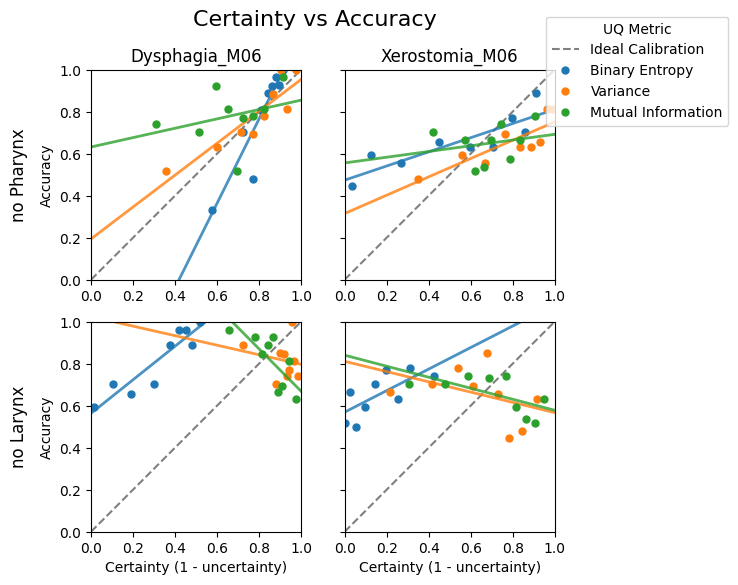

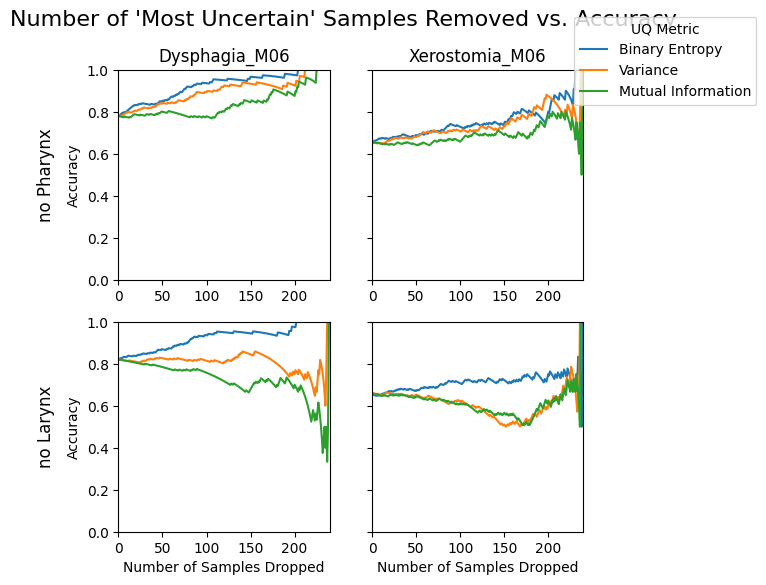

In [5]:
from src.uncertainty.visualisation.plotting_UQ import plot_nested_UQ

# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="error calibration", row_key="method", col_key="endpoint", N_bins=5)
# plt.show()

# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="prediction_calibration", row_key="method", 
#                      col_key="endpoint", N_bins=5, normalisation_method=None) # predictions
# plt.show()

fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="UQ_calibration", row_key="method", 
                     col_key="endpoint", N_bins=5, normalisation_method="minmax") # predictions
plt.show()

fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="sparsification", row_key="method", col_key="endpoint")
plt.show()


In [6]:
df_results = UQ_RESULTS_DICT['Xerostomia_M06']['no Larynx']
df_pharynx_results = df_results[df_results['PatientID'].isin(df_PRIMA[df_PRIMA['Loctum2'] == 'Pharynx']['PatientID'])]
df_pharynx_results

print(df_pharynx_results['Mean Prediction'].mean(), df_pharynx_results['Binary Entropy'].mean(), df_pharynx_results['Mutual Information'].mean(), df_pharynx_results['Variance'].mean())


df_larynx_results = df_results[df_results['PatientID'].isin(df_PRIMA[df_PRIMA['Loctum2'] == 'Larynx']['PatientID'])]
df_larynx_results

print(df_larynx_results['Mean Prediction'].mean(), df_larynx_results['Binary Entropy'].mean(), df_larynx_results['Mutual Information'].mean(), df_larynx_results['Variance'].mean()  )
# df_pharynx = df_PRIMA[df_PRIMA['PatientID'].isin(UQ_RESULTS_DICT['Xerostomia_M06']['no Pharynx']['PatientID'])]
# df_pharynx = UQ_RESULTS_DICT['Xerostomia_M06']['no Pharynx'][UQ_RESULTS_DICT['Xerostomia_M06']['no Pharynx']['True Labels'] != -1]
# df_larynx = df_PRIMA[df_PRIMA['PatientID'].isin(UQ_RESULTS_DICT['Xerostomia_M06']['no Larynx']['PatientID'])]

0.4205450222123967 0.8841148178242647 0.010156147151872014 0.0028463580625023095
0.23842218785192307 0.7648319631632413 0.017452067312821097 0.004206706179291873


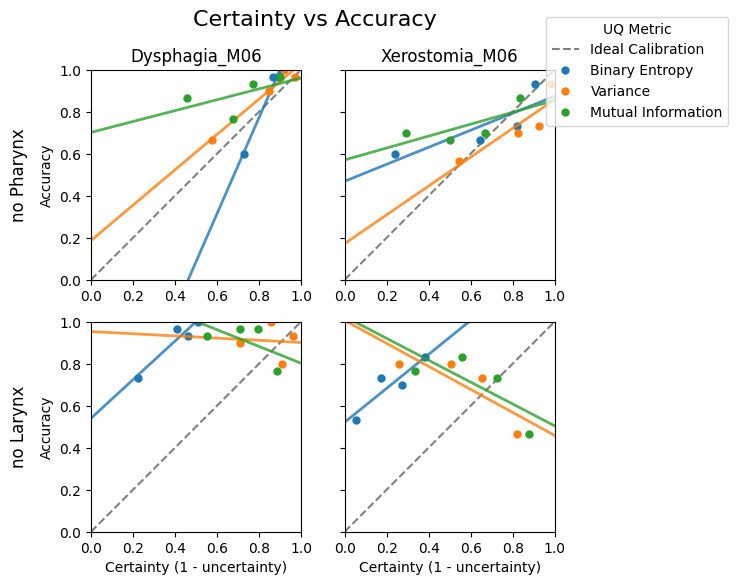

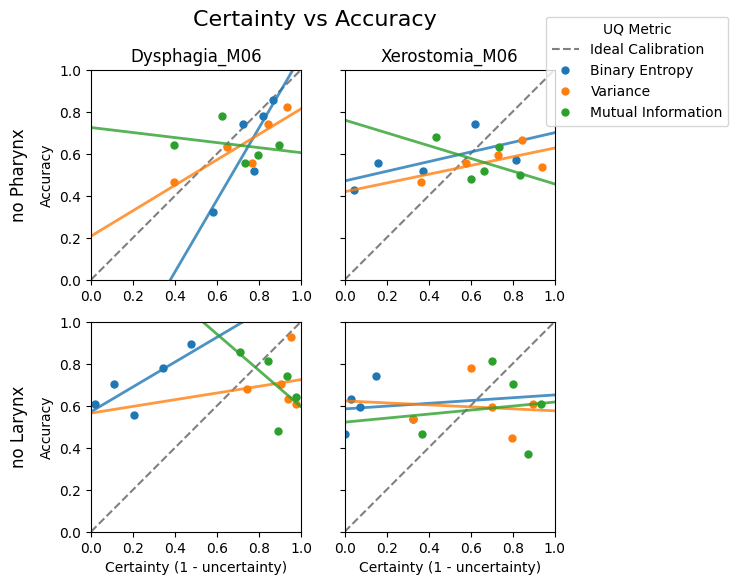

In [11]:
import copy

UQ_RESULTS_DICT_no_pharynx = copy.deepcopy(UQ_RESULTS_DICT)
pharynx_patient_ids = set(df_PRIMA[df_PRIMA['Loctum2'] == 'Pharynx']['PatientID'])

for endpoint in UQ_RESULTS_DICT_no_pharynx:
    for method in UQ_RESULTS_DICT_no_pharynx[endpoint]:
        df = UQ_RESULTS_DICT_no_pharynx[endpoint][method]
        UQ_RESULTS_DICT_no_pharynx[endpoint][method] = df[~df['PatientID'].isin(pharynx_patient_ids)]

fig = plot_nested_UQ(UQ_RESULTS_DICT_no_pharynx, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="UQ_calibration", row_key="method", 
                     col_key="endpoint", N_bins=5, normalisation_method="minmax") # predictions
plt.show()



UQ_RESULTS_DICT_no_larynx = copy.deepcopy(UQ_RESULTS_DICT)
larynx_patient_ids = set(df_PRIMA[df_PRIMA['Loctum2'] == 'Larynx']['PatientID'])

for endpoint in UQ_RESULTS_DICT_no_larynx:
    for method in UQ_RESULTS_DICT_no_larynx[endpoint]:
        df = UQ_RESULTS_DICT_no_larynx[endpoint][method]
        UQ_RESULTS_DICT_no_larynx[endpoint][method] = df[~df['PatientID'].isin(larynx_patient_ids)]

fig = plot_nested_UQ(UQ_RESULTS_DICT_no_larynx, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="UQ_calibration", row_key="method", 
                     col_key="endpoint", N_bins=5, normalisation_method="minmax") # predictions
plt.show()

In [7]:
df_pharynx_results

,Mean Prediction,PatientID,True Labels,Mutual Information,Binary Entropy,Variance
1,0.199674,11319,1.0,0.025762,0.721275,0.006262
4,0.636710,11967,1.0,0.008663,0.945380,0.002834
5,0.320071,12098,0.0,0.009765,0.904459,0.003047
6,0.452140,12213,0.0,0.004998,0.993381,0.001746
10,0.294097,13051,0.0,0.010080,0.873955,0.002972
...,...,...,...,...,...,...
233,0.160870,95589,1.0,0.027018,0.636386,0.005476
234,0.319927,96957,0.0,0.009093,0.904302,0.002820
235,0.394243,97410,0.0,0.004874,0.967483,0.001652
236,0.521505,97534,1.0,0.005618,0.998665,0.001976
